<a href="https://colab.research.google.com/github/AqsaAamena/Basic-Python-Projects/blob/main/Assignment_18(Optional_Task).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

Loaded insurance dataset. Shape: (1338, 7)

Dataset loaded and duplicates removed. Shape: (1337, 7)

--- Initial Dataset (First 5 Rows)
   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86

--- Summary Statistics of Numerical Data ---
               age          bmi     children      expenses
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.665520     1.095737  13279.121638
std      14.044333     6.100664     1.205571  12110.359657
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4746.340000
50%      39.000000    30.400000     1.000000   9386.160000
75%      51.000000    34.700000     2.000000  16657

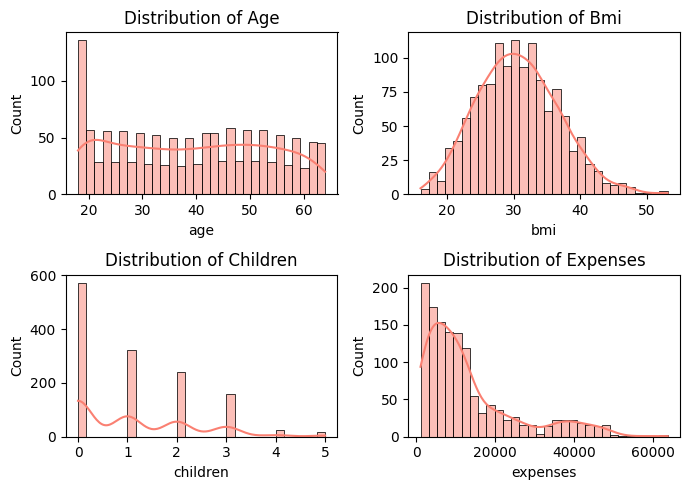

/tmp/ipykernel_7072/3250596379.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ins, x=col, order=df_ins[col].value_counts().index, palette='muted')
/tmp/ipykernel_7072/3250596379.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ins, x=col, order=df_ins[col].value_counts().index, palette='muted')
/tmp/ipykernel_7072/3250596379.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ins, x=col, order=df_ins[col].value_counts().index, palette='muted')


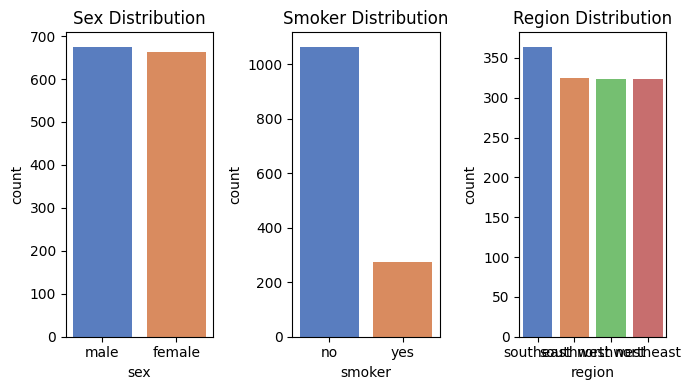


--- Statistical Summary of Numerical Data ---
               age          bmi     children      expenses
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.665520     1.095737  13279.121638
std      14.044333     6.100664     1.205571  12110.359657
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4746.340000
50%      39.000000    30.400000     1.000000   9386.160000
75%      51.000000    34.700000     2.000000  16657.720000
max      64.000000    53.100000     5.000000  63770.430000

--- Final Preprocessed Insurance Dataset (First 5 Rows) ---
        age       bmi  children  expenses  sex_male  smoker_yes  \
0 -1.440418 -0.453484 -0.909234  16884.92     False        True   
1 -1.511647  0.513986 -0.079442   1725.55      True       False   
2 -0.799350  0.382803  1.580143   4449.46      True       False   
3 -0.443201 -1.306169 -0.909234  21984.47      True       False   
4 -0.514431 -0.289506 -0.9

In [5]:
# STEP 1: Load and Clean the Data (From Q1 & Q2)
df_ins = pd.read_csv('insurance.csv')
print(f"Loaded insurance dataset. Shape: {df_ins.shape}")

# Handle duplicate rows exactly like Q2
df_ins.drop_duplicates(inplace=True)
print(f"\nDataset loaded and duplicates removed. Shape: {df_ins.shape}")

# STEP 2: EDA Visualizations
print("\n--- Initial Dataset (First 5 Rows)")
print(df_ins.head())
print("\n--- Missing Values in Each Column ---")
print(df_ins.isnull().sum())
print()
# Histograms
numeric_cols_ins = ['age', 'bmi', 'children', 'expenses']
plt.figure(figsize=(7, 5))
for i, col in enumerate(numeric_cols_ins, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_ins[col], kde=True, bins=30, color='salmon')
    plt.title(f'Distribution of {col.capitalize()}')
plt.tight_layout()
plt.show()

# Count Plots
categorical_cols_ins = ['sex', 'smoker', 'region']
plt.figure(figsize=(7, 4))
for i, col in enumerate(categorical_cols_ins, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df_ins, x=col, order=df_ins[col].value_counts().index, palette='muted')
    plt.title(f'{col.capitalize()} Distribution')
plt.tight_layout()
plt.show()

# CONCEPT 1: Dynamic Data Type Splitting
# Using select_dtypes to dynamically separate our column types for summary stats
print("\n--- Statistical Summary of Numerical Data ---")
print(df_ins.select_dtypes(include=['number']).describe())

# CONCEPT 2: Feature Isolation
# Clearly defining our inputs vs target target before transformations
target_variable = 'expenses'
independent_features = [col for col in df_ins.columns if col != target_variable]

# STEP 3: Encode Categorical Variables
# One-hot encoding the text features
df_ins_encoded = pd.get_dummies(df_ins, columns=categorical_cols_ins, drop_first=True)

# STEP 4: Scale the Numeric Inputs
# Isolating only the independent numeric features to scale (excluding 'charges')
numeric_independent_ins = ['age', 'bmi', 'children']

scaler_ins = StandardScaler()
df_ins_encoded[numeric_independent_ins] = scaler_ins.fit_transform(df_ins_encoded[numeric_independent_ins])

# Final Pipeline Verification
print("\n--- Final Preprocessed Insurance Dataset (First 5 Rows) ---")
print(df_ins_encoded.head(5))
print(f"\nFinal dataset shape ready for ML: {df_ins_encoded.shape}")